In [1]:
from pathlib import Path
import logging, sys, os

ROOT      = r"D:\RGEALTI"
COG_DIR   = Path(ROOT) / "COG_5m"      # sorties étape 1
VRT_DIR   = Path(ROOT) / "VRT"; VRT_DIR.mkdir(parents=True, exist_ok=True)
CAT_PATH  = VRT_DIR / "catalog.parquet"  # index persistant
AOI_BUFFER_M = 10000  # ex: 10 km
FORCE_CRS = "EPSG:2154"

In [2]:
def setup_logger(name="vrt", level=logging.INFO):
    log = logging.getLogger(name); log.setLevel(level)
    if not log.handlers:
        h = logging.StreamHandler(sys.stdout)
        h.setFormatter(logging.Formatter("[%(levelname)s] %(message)s"))
        log.addHandler(h)
    return log

log = setup_logger()

In [3]:
import pandas as pd
import rasterio
from glob import glob
from tqdm import tqdm

def build_catalog(cog_dir: Path, cat_path: Path):
    files = glob(str(cog_dir / "*.tif"))
    rows = []
    for f in tqdm(files, desc="Scan COG bounds"):
        try:
            with rasterio.open(f) as ds:
                b = ds.bounds
                rows.append((f, b.left, b.bottom, b.right, b.top))
        except Exception as e:
            log.error(f"Lecture échouée: {f} | {e}")
    df = pd.DataFrame(rows, columns=["path","minx","miny","maxx","maxy"])
    df.to_parquet(cat_path, index=False)
    log.info(f"Catalog: {len(df)} rasters → {cat_path}")
    return df

def load_or_build_catalog():
    if CAT_PATH.exists():
        log.info(f"Catalog existant: {CAT_PATH}")
        return pd.read_parquet(CAT_PATH)
    return build_catalog(COG_DIR, CAT_PATH)

catalog = load_or_build_catalog()
catalog

[INFO] Catalog existant: D:\RGEALTI\VRT\catalog.parquet


,path,minx,miny,maxx,maxy
0,D:\RGEALTI\COG_5m\D001_0830_6540_MNT5m.tif,829997.5,6535002.5,834997.5,6540002.5
1,D:\RGEALTI\COG_5m\D001_0830_6545_MNT5m.tif,829997.5,6540002.5,834997.5,6545002.5
2,D:\RGEALTI\COG_5m\D001_0830_6550_MNT5m.tif,829997.5,6545002.5,834997.5,6550002.5
3,D:\RGEALTI\COG_5m\D001_0830_6555_MNT5m.tif,829997.5,6550002.5,834997.5,6555002.5
4,D:\RGEALTI\COG_5m\D001_0830_6560_MNT5m.tif,829997.5,6555002.5,834997.5,6560002.5
...,...,...,...,...,...
26858,D:\RGEALTI\COG_5m\D095_0665_6885_MNT5m.tif,664997.5,6880002.5,669997.5,6885002.5
26859,D:\RGEALTI\COG_5m\D095_0665_6890_MNT5m.tif,664997.5,6885002.5,669997.5,6890002.5
26860,D:\RGEALTI\COG_5m\D095_0665_6895_MNT5m.tif,664997.5,6890002.5,669997.5,6895002.5
26861,D:\RGEALTI\COG_5m\D095_0670_6885_MNT5m.tif,669997.5,6880002.5,674997.5,6885002.5


In [34]:
catalog.describe()

,minx,miny,maxx,maxy
count,2.686300e+04,2.686300e+04,2.686300e+04,2.686300e+04
mean,6.564078e+05,6.607061e+06,6.614078e+05,6.612061e+06
std,2.060022e+05,2.310501e+05,2.060022e+05,2.310501e+05
min,9.499750e+04,6.135002e+06,9.999750e+04,6.140002e+06
25%,4.999975e+05,6.405002e+06,5.049975e+05,6.410002e+06
50%,6.549975e+05,6.625002e+06,6.599975e+05,6.630002e+06
75%,8.249975e+05,6.805002e+06,8.299975e+05,6.810002e+06
max,1.079998e+06,7.110002e+06,1.084998e+06,7.115002e+06


In [4]:
from rtree import index as rtree_index

def build_rtree(df):
    props = rtree_index.Property()
    props.leaf_capacity = 100
    idx = rtree_index.Index(properties=props)
    for i, r in df.iterrows():
        idx.insert(i, (r.minx, r.miny, r.maxx, r.maxy))
    log.info(f"R-tree construit: {len(df)} entrées")
    return idx

rt = build_rtree(catalog)

[INFO] R-tree construit: 26863 entrées


In [35]:
rt

rtree.index.Index(bounds=[94997.5, 6135002.5, 1084997.5, 7115002.5], size=26863)

In [15]:
from shapely.geometry import box

def select_sources(df, rtree, aoi_bounds, buffer_m=0):
    minx, miny, maxx, maxy = aoi_bounds
    q = (minx-buffer_m, miny-buffer_m, maxx+buffer_m, maxy+buffer_m)
    hits = list(rtree.intersection(q))
    if not hits: return [], q
    aoi_poly = box(*q)
    keep = df.iloc[hits].apply(
        lambda r: aoi_poly.intersects(box(r.minx, r.miny, r.maxx, r.maxy)), axis=1
    )
    return df.iloc[hits][keep], q

In [16]:
import numpy as np
import pandas as pd
import rasterio
from rasterio.windows import from_bounds, Window
from rasterio.transform import from_origin

def read_mosaic(bounds, out_res, sources_df, crs="EPSG:2154"):
    minx, miny, maxx, maxy = bounds
    # grille de sortie
    width  = int(np.ceil((maxx - minx) / out_res))
    height = int(np.ceil((maxy - miny) / out_res))
    if width <= 0 or height <= 0:
        raise ValueError("AOI invalide: largeur/hauteur nulles.")
    transform = from_origin(minx, maxy, out_res, out_res)

    out = np.full((height, width), np.nan, dtype=np.float32)
    out_mask = np.zeros((height, width), dtype=bool)  # True si déjà écrit

    for _, r in sources_df.iterrows():
        path = r["path"]
        src_nodata = r["nodata"] if ("nodata" in r and not pd.isna(r["nodata"])) else None

        with rasterio.open(path) as src:
            # 1) test d’intersection rapide au niveau bbox
            sb = src.bounds
            ix_minx = max(minx, sb.left)
            ix_miny = max(miny, sb.bottom)
            ix_maxx = min(maxx, sb.right)
            ix_maxy = min(maxy, sb.top)
            if not (ix_minx < ix_maxx and ix_miny < ix_maxy):
                continue  # pas d’intersection

            # 2) fenêtre source à partir de la bbox intersectée
            win_src = from_bounds(ix_minx, ix_miny, ix_maxx, ix_maxy, transform=src.transform)
            # clamp stricte aux limites source + arrondis entiers
            full_src = Window(0, 0, src.width, src.height)
            try:
                win_src = win_src.intersection(full_src).round_offsets().round_lengths()
            except Exception:
                # si intersection vide au final
                continue
            if win_src.width <= 0 or win_src.height <= 0:
                continue

            # 3) bbox exacte de la fenêtre source, puis fenêtre cible correspondante
            ib = rasterio.windows.bounds(win_src, src.transform)
            win_dst = from_bounds(*ib, transform=transform).round_offsets().round_lengths()
            if win_dst.width <= 0 or win_dst.height <= 0:
                continue

            # 4) lecture
            arr = src.read(1, window=win_src, masked=False)

            # 5) masque valide
            if src_nodata is None:
                valid = np.isfinite(arr)
            else:
                valid = arr != src_nodata

            # 6) harmonisation tailles (décalages d’1 px possibles)
            h = min(int(win_dst.height), arr.shape[0])
            w = min(int(win_dst.width),  arr.shape[1])
            if h <= 0 or w <= 0:
                continue

            r0, c0 = int(win_dst.row_off), int(win_dst.col_off)

            # borne sécurisée si la fenêtre déborde marginalement la grille sortie
            if r0 < 0 or c0 < 0 or (r0+h) > height or (c0+w) > width:
                r1 = max(r0, 0); c1 = max(c0, 0)
                r2 = min(r0 + h, height); c2 = min(c0 + w, width)
                if r2 <= r1 or c2 <= c1:
                    continue
                # recaler arr/valid sur la même sous-fenêtre
                arr = arr[(r1 - r0):(r1 - r0) + (r2 - r1), (c1 - c0):(c1 - c0) + (c2 - c1)]
                valid = valid[(r1 - r0):(r1 - r0) + (r2 - r1), (c1 - c0):(c1 - c0) + (c2 - c1)]
                r0, c0, h, w = r1, c1, (r2 - r1), (c2 - c1)

            upd = (~out_mask[r0:r0+h, c0:c0+w]) & valid[:h, :w]
            if np.any(upd):
                sl = out[r0:r0+h, c0:c0+w]
                sl[upd] = arr[:h, :w][upd].astype(np.float32, copy=False)
                out_mask[r0:r0+h, c0:c0+w][upd] = True

    out[np.isnan(out)] = -99999.0
    return out, transform, crs


In [22]:
# AAOI Lucinges
# AAOI bbox (EPSG:2154): (945331.4633142418, 6561534.405115804, 966674.0269534773, 6582876.968755038) | buffer ombre B=5.7 km
AOI_BOUNDS = (945331.4633142418, 6561534.405115804, 966674.0269534773, 6582876.968755038)
sources_df, AOI_EXPANDED = select_sources(catalog, rt, AOI_BOUNDS, buffer_m=10000)
print(f"[INFO] Sources retenues: {len(sources_df)}")

[INFO] Sources retenues: 77


In [23]:
# Inspecte la première source
p0 = sources_df.iloc[0]["path"]
import rasterio
with rasterio.open(p0) as ds:
    print("AOI:", AOI_BOUNDS)
    print("SRC bounds:", ds.bounds)


AOI: (945331.4633142418, 6561534.405115804, 966674.0269534773, 6582876.968755038)
SRC bounds: BoundingBox(left=934997.5, bottom=6575002.5, right=939997.5, top=6580002.5)


In [24]:
OUT_RES = 5.0
tile_arr, tile_transform, tile_crs = read_mosaic(AOI_BOUNDS, OUT_RES, sources_df)

# Écriture GeoTIFF compact sans GDAL/osgeo
import rasterio
meta = {
    "driver":"GTiff","height":tile_arr.shape[0],"width":tile_arr.shape[1],
    "count":1,"dtype":"float32","crs":tile_crs,"transform":tile_transform,
    "nodata":-99999.0, "tiled":True, "compress":"DEFLATE", "predictor":2,
    "blockxsize":512, "blockysize":512
}
out_tif = COG_DIR.parent / "VRT" / "mosaic_tile.tif"
with rasterio.open(out_tif, "w", **meta) as dst:
    dst.write(tile_arr, 1)
print(f"[OK] {out_tif}")


[OK] D:\RGEALTI\VRT\mosaic_tile.tif


In [25]:
import pvlib
import pandas as pd
from datetime import datetime, timezone

# Coordonnées du centre de ta tuile (en degrés WGS84)
lon, lat = 6.32095, 46.201238
date_utc = datetime(2025, 10, 31, 13, 0, 0, tzinfo=timezone.utc)

solpos = pvlib.solarposition.get_solarposition(
    time=pd.DatetimeIndex([date_utc]),
    latitude=lat,
    longitude=lon
).iloc[0]

azimuth = solpos.azimuth        # en degrés (0° = nord, sens horaire)
elevation = solpos.elevation    # hauteur du soleil au-dessus de l’horizon
print(f"Azimut={azimuth:.2f}°, Hauteur={elevation:.2f}°")


Azimut=207.39°, Hauteur=25.31°


In [26]:
import numpy as np
import rasterio
from numba import njit, prange

def read_dem(path):
    with rasterio.open(path) as ds:
        z = ds.read(1).astype(np.float32)
        transform = ds.transform
        nodata = ds.nodatavals[0]
    return z, transform, nodata

dem, transform, nodata = read_dem(out_tif)
res = transform.a  # 5 m

@njit(parallel=True, fastmath=True)
def shadow_mask(dem, res, az_deg, elev_deg, nodata_val=-99999.0):
    nrows, ncols = dem.shape
    mask = np.zeros_like(dem, dtype=np.uint8)
    az = np.deg2rad(az_deg)
    elev = np.deg2rad(elev_deg)
    dzdx = np.cos(az)
    dzdy = np.sin(az)
    tan_sun = np.tan(elev)
    step = int(2000 / res)  # 10 km max rayon de recherche; ajustable

    for r in prange(nrows):
        for c in range(ncols):
            z0 = dem[r, c]
            if z0 <= nodata_val:  # skip NODATA
                continue
            # direction (dx, dy)
            x, y = c, r
            visible = True
            for k in range(1, step):
                xk = c + k * dzdx
                yk = r - k * dzdy
                if xk < 0 or yk < 0 or xk >= ncols or yk >= nrows:
                    break
                zt = dem[int(yk), int(xk)]
                if zt <= nodata_val:
                    continue
                if (zt - z0) / (k * res) > tan_sun:
                    visible = False
                    break
            mask[r, c] = 0 if visible else 1
    return mask


In [27]:
az, elev = float(azimuth), float(elevation)
shadow = shadow_mask(dem, res, az, elev, nodata)

out_path = r"D:\RGEALTI\VRT\shadow_mask.tif"
meta = {
    "driver": "GTiff",
    "height": shadow.shape[0],
    "width": shadow.shape[1],
    "count": 1,
    "dtype": "uint8",
    "crs": "EPSG:2154",
    "transform": transform,
    "compress": "DEFLATE",
    "tiled": True,
    "blockxsize": 512,
    "blockysize": 512,
    "nodata": 255
}
with rasterio.open(out_path, "w", **meta) as dst:
    dst.write(shadow, 1)

print(f"→ masque d'ombre: {out_path}")


→ masque d'ombre: D:\RGEALTI\VRT\shadow_mask.tif


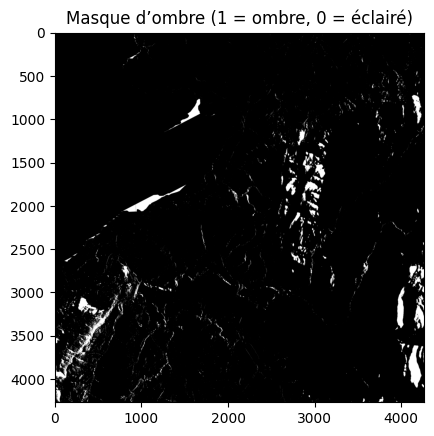

In [28]:
import matplotlib.pyplot as plt
plt.imshow(shadow, cmap="gray")
plt.title("Masque d’ombre (1 = ombre, 0 = éclairé)")
plt.show()


In [29]:
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from pathlib import Path

src_path = r"D:\RGEALTI\VRT\shadow_mask.tif"
dst_path = r"D:\RGEALTI\VRT\shadow_mask_3857.tif"

with rasterio.open(src_path) as src:
    transform, width, height = calculate_default_transform(
        src.crs, "EPSG:3857", src.width, src.height, *src.bounds, resolution=src.res[0]
    )

    profile = src.profile.copy()
    profile.update({
        "crs": "EPSG:3857",
        "transform": transform,
        "width": width,
        "height": height,
        "compress": "DEFLATE",
        "predictor": 2,
        "blockxsize": 512,
        "blockysize": 512,
        "tiled": True,
        "nodata": 255,
        "dtype": "uint8"
    })

    with rasterio.open(dst_path, "w", **profile) as dst:
        reproject(
            source=rasterio.band(src, 1),
            destination=rasterio.band(dst, 1),
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs="EPSG:3857",
            resampling=Resampling.nearest
        )

print(f"[OK] {dst_path}")


[OK] D:\RGEALTI\VRT\shadow_mask_3857.tif


In [31]:
# -*- coding: utf-8 -*-
import os
from pathlib import Path
import math
import logging, sys
import numpy as np
from PIL import Image
from tqdm import tqdm

import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.windows import from_bounds

# -------------------------
# Logging
# -------------------------
def setup_logger(level=logging.INFO):
    log = logging.getLogger("rasterio_web")
    log.setLevel(level)
    if not log.handlers:
        h = logging.StreamHandler(sys.stdout)
        h.setFormatter(logging.Formatter("[%(levelname)s] %(message)s"))
        log.addHandler(h)
    return log

log = setup_logger()

# -------------------------
# Paramètres
# -------------------------
SRC_MASK_2154 = r"D:\RGEALTI\VRT\shadow_mask.tif"        # masque binaire 0/1, EPSG:2154
DST_MASK_3857 = r"D:\RGEALTI\VRT\shadow_mask_3857.tif"   # sortie reprojetée
TILES_DIR      = Path(r"D:\RGEALTI\VRT\tiles_shadow")    # tuiles PNG
ZOOM_MIN, ZOOM_MAX = 8, 16                               # niveaux XYZ à produire
TILE_SIZE = 256                                          # Leaflet/XYZ standard
NODATA_IN  = 255                                         # NODATA du masque
ALPHA_ON   = 160                                         # opacité pour les pixels d’ombre=1
ALPHA_OFF  = 0                                           # transparent pour 0/NODATA

# -------------------------
# 1) Reprojection 2154 -> 3857
# -------------------------
def reproject_to_3857(src_path, dst_path, nodata=NODATA_IN):
    with rasterio.open(src_path) as src:
        # On garde ~la maille équivalente en mètres
        transform, width, height = calculate_default_transform(
            src.crs, "EPSG:3857", src.width, src.height, *src.bounds, resolution=src.res[0]
        )
        profile = src.profile.copy()
        profile.update({
            "driver": "GTiff",
            "crs": "EPSG:3857",
            "transform": transform,
            "width": width,
            "height": height,
            "dtype": "uint8",
            "count": 1,
            "tiled": True,
            "blockxsize": 512,
            "blockysize": 512,
            "compress": "DEFLATE",
            "predictor": 2,
            "nodata": nodata
        })
        Path(dst_path).parent.mkdir(parents=True, exist_ok=True)
        log.info(f"Reprojection → 3857 : {src_path} → {dst_path}")
        with rasterio.open(dst_path, "w", **profile) as dst:
            reproject(
                source=rasterio.band(src, 1),
                destination=rasterio.band(dst, 1),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs="EPSG:3857",
                resampling=Resampling.nearest,
                src_nodata=src.nodata,
                dst_nodata=nodata
            )

# -------------------------
# 2) Outils WebMercator (3857)
# -------------------------
ORIGIN_SHIFT = 20037508.342789244  # demi-circonférence projetée (m)
INITIAL_RES  = 2 * math.pi * 6378137 / TILE_SIZE  # ≈ 156543.03392804097 m/px au zoom 0

def resolution(z):
    return INITIAL_RES / (2 ** z)   # m/px à l’équateur (uniforme en 3857)

def meters_to_tile(minx, miny, maxx, maxy, z):
    """Convertit une bbox en mètres 3857 → plage d'indices XYZ inclusifs (x0..x1, y0..y1)."""
    res = resolution(z)
    # Coord → pixels globaux
    px_min = (minx + ORIGIN_SHIFT) / res
    py_max = (ORIGIN_SHIFT - maxy) / res
    px_max = (maxx + ORIGIN_SHIFT) / res
    py_min = (ORIGIN_SHIFT - miny) / res
    # Pixels → tuiles
    tx0 = int(math.floor(px_min / TILE_SIZE))
    ty0 = int(math.floor(py_min / TILE_SIZE))
    tx1 = int(math.floor(px_max / TILE_SIZE))
    ty1 = int(math.floor(py_max / TILE_SIZE))
    # Clamp dans l’étendue du zoom
    max_index = (2 ** z) - 1
    tx0 = max(0, min(tx0, max_index)); tx1 = max(0, min(tx1, max_index))
    ty0 = max(0, min(ty0, max_index)); ty1 = max(0, min(ty1, max_index))
    return tx0, ty0, tx1, ty1

def tile_bounds_meters(x, y, z):
    """Renvoie la bbox d’une tuile XYZ (x,y,z) en mètres 3857: (minx,miny,maxx,maxy)."""
    res = resolution(z)
    minx = x * TILE_SIZE * res - ORIGIN_SHIFT
    maxx = (x + 1) * TILE_SIZE * res - ORIGIN_SHIFT
    maxy = ORIGIN_SHIFT - y * TILE_SIZE * res
    miny = ORIGIN_SHIFT - (y + 1) * TILE_SIZE * res
    return (minx, miny, maxx, maxy)

# -------------------------
# 3) Lecture fenêtrée et écriture PNG
# -------------------------
def render_rgba_from_mask(arr_uint8, nodata=NODATA_IN):
    """
    arr_uint8: 2D uint8 (valeurs attendues: 0=clair, 1=ombre, NODATA=255)
    Sortie: RGBA uint8, noir pour 1, transparent sinon.
    """
    h, w = arr_uint8.shape
    rgba = np.zeros((h, w, 4), dtype=np.uint8)
    # Ombre = 1 -> noir + alpha
    shadow = (arr_uint8 == 1)
    rgba[..., 3][shadow] = ALPHA_ON
    # clair (0) et nodata (255) restent alpha 0
    return rgba

def save_tile_png(rgba, out_png):
    Image.fromarray(rgba, mode="RGBA").save(out_png, optimize=True)

def generate_xyz_tiles(mask_3857_path, out_dir, z_min, z_max):
    out_dir = Path(out_dir); out_dir.mkdir(parents=True, exist_ok=True)
    with rasterio.open(mask_3857_path) as ds:
        ds_bounds = ds.bounds  # en mètres 3857
        log.info(f"Bounds 3857: {ds_bounds.left:.1f},{ds_bounds.bottom:.1f},"
                 f"{ds_bounds.right:.1f},{ds_bounds.top:.1f}")
        for z in range(z_min, z_max + 1):
            tx0, ty0, tx1, ty1 = meters_to_tile(ds_bounds.left, ds_bounds.bottom,
                                                ds_bounds.right, ds_bounds.top, z)
            total = (tx1 - tx0 + 1) * (ty1 - ty0 + 1)
            log.info(f"Zoom {z}: tuiles {total} [{tx0}:{tx1}]x[{ty0}:{ty1}]")
            for ty in tqdm(range(ty0, ty1 + 1), desc=f"z{z}", unit="row"):
                for tx in range(tx0, tx1 + 1):
                    tb = tile_bounds_meters(tx, ty, z)
                    # Fenêtre dans le raster 3857 au plus proche
                    win = from_bounds(*tb, transform=ds.transform).round_offsets().round_lengths()
                    if win.width <= 0 or win.height <= 0:
                        continue
                    # Lecture resamplée sur 256x256
                    out = np.empty((1, TILE_SIZE, TILE_SIZE), dtype=np.uint8)
                    rasterio.warp.reproject(
                        source=rasterio.band(ds, 1),
                        destination=out,
                        src_transform=ds.transform,
                        src_crs=ds.crs,
                        dst_transform=rasterio.transform.from_bounds(*tb, TILE_SIZE, TILE_SIZE),
                        dst_crs=ds.crs,
                        resampling=Resampling.nearest,
                        src_nodata=ds.nodata,
                        dst_nodata=NODATA_IN
                    )
                    rgba = render_rgba_from_mask(out[0], nodata=NODATA_IN)

                    # Arborescence XYZ {z}/{x}/{y}.png
                    out_png = out_dir / str(z) / str(tx) / f"{ty}.png"
                    out_png.parent.mkdir(parents=True, exist_ok=True)
                    save_tile_png(rgba, out_png)


# 1) reprojection
if not Path(DST_MASK_3857).exists():
    reproject_to_3857(SRC_MASK_2154, DST_MASK_3857, nodata=NODATA_IN)
else:
    log.info(f"Skip reprojection (existe): {DST_MASK_3857}")

# 2) tuiles XYZ
generate_xyz_tiles(DST_MASK_3857, TILES_DIR, ZOOM_MIN, ZOOM_MAX)

log.info("Terminé. Servez TILES_DIR via un serveur statique et ajoutez la couche dans Leaflet.")


[INFO] Skip reprojection (existe): D:\RGEALTI\VRT\shadow_mask_3857.tif
[INFO] Bounds 3857: 687632.0,5796565.2,719717.0,5828750.2
[INFO] Zoom 8: tuiles 1 [132:132]x[90:90]


z8: 100%|██████████| 1/1 [00:00<00:00,  8.15row/s]

[INFO] Zoom 9: tuiles 2 [264:265]x[181:181]



z9: 100%|██████████| 1/1 [00:00<00:00, 24.62row/s]

[INFO] Zoom 10: tuiles 2 [529:530]x[363:363]


...

[INFO] Zoom 15: tuiles -675 [16946:16972]x[11644:11618]



z15: 0row [00:00, ?row/s]

[INFO] Zoom 16: tuiles -2703 [33892:33944]x[23288:23236]



z16: 0row [00:00, ?row/s]

[INFO] Terminé. Servez TILES_DIR via un serveur statique et ajoutez la couche dans Leaflet.


In [33]:
from PIL import Image
import numpy as np
from glob import glob
tiles_dir = 'D:\\RGEALTI\\VRT\\tiles_shadow\\'

for png in glob(str(tiles_dir + "**/*.png"), recursive=True):
    im = Image.open(png).convert("L")
    arr = np.array(im)
    rgba = np.zeros((arr.shape[0], arr.shape[1], 4), dtype=np.uint8)
    rgba[..., 0:3] = 0      # noir
    rgba[..., 3] = (arr == 1) * 150  # alpha
    Image.fromarray(rgba, "RGBA").save(png)
